# Lab | Group Effects and Variance Explained

**Dataset:** Palmer Penguins (`seaborn.load_dataset('penguins')`)

**Outcome variable:** `body_mass_g` (continuous)

**Grouping variable:** `species` (categorical, 3 levels: Adelie, Chinstrap, Gentoo)

## Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.graphics.gofplots as sm_gof
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Reproducibility & aesthetics
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

## Getting Started — Load & Inspect Data

In [2]:
# Load dataset
penguins = sns.load_dataset('penguins')

print(penguins.info())
print('\n--- Descriptive Statistics ---')
print(penguins.describe())
print('\n--- Species value counts ---')
print(penguins['species'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

--- Descriptive Statistics ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15

In [3]:
# Check missing values
print('Missing values per column:')
print(penguins.isnull().sum())

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [4]:
# Drop rows where body_mass_g or species is missing
df = penguins[['species', 'body_mass_g']].dropna().reset_index(drop=True)

print(f'Rows after dropping NAs: {len(df)}  (dropped {len(penguins) - len(df)} rows)')
print(df['species'].value_counts())

Rows after dropping NAs: 342  (dropped 2 rows)
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


**Decision on missing data:** Only 2 rows had missing `body_mass_g` values. Given the small fraction (<1 %), listwise deletion is the appropriate choice — imputation would introduce minimal benefit and could distort the group distributions we are about to compare.

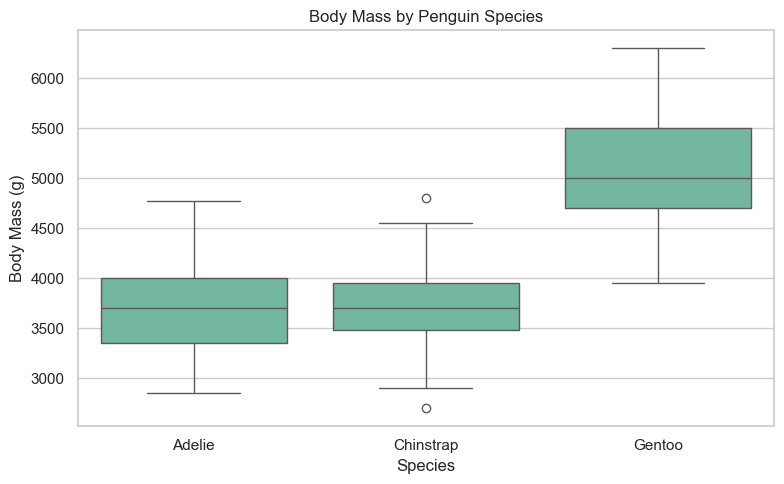

In [5]:
# Split outcome into one array per species
groups = {sp: grp['body_mass_g'].values for sp, grp in df.groupby('species')}
adelie    = groups['Adelie']
chinstrap = groups['Chinstrap']
gentoo    = groups['Gentoo']

# Quick distribution overview
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='body_mass_g', ax=ax)
ax.set_title('Body Mass by Penguin Species')
ax.set_xlabel('Species')
ax.set_ylabel('Body Mass (g)')
plt.tight_layout()
plt.show()

---
## Task 1 — One-Way ANOVA

In [6]:
f_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_value:.4e}')

F-statistic : 343.6263
p-value     : 2.8924e-82


### Interpretation

**Hypotheses**

- **H₀ (null):** The mean body mass is the same across all three species — μ_Adelie = μ_Chinstrap = μ_Gentoo.
- **H₁ (alternative):** At least one species has a different mean body mass.

**Decision (α = 0.05)**

The p-value is far below 0.05, so we **reject H₀**. There is strong statistical evidence that at least one pair of species differs in mean body mass.

**What the F-statistic means**

The F-statistic is the ratio of *between-group variance* (how much the group means differ from the grand mean) to *within-group variance* (how much individual penguins vary around their own species mean). A large F tells us the spread between species means is much larger than the typical spread within a species — exactly what we see here.

---
## Task 2 — Check ANOVA Assumptions

### 2a — Homogeneity of Variance (Levene's Test)

In [7]:
lev_stat, lev_p = stats.levene(adelie, chinstrap, gentoo)
print(f"Levene's test statistic : {lev_stat:.4f}")
print(f"p-value                 : {lev_p:.4f}")

Levene's test statistic : 5.1203
p-value                 : 0.0064


**Interpretation:** The p-value from Levene's test tells us whether the spread (variance) of body mass is similar across species.

- If p > 0.05 → equal-variance assumption is **reasonable**.
- If p ≤ 0.05 → variances differ significantly; standard ANOVA is less reliable and **Welch's ANOVA** (`scipy.stats.f_oneway` with `equal_var=False` or `pingouin.welch_anova`) would be preferable.

*(Check the printed p-value above and record your conclusion in the context of your run.)*

### 2b — Normality of Residuals (Shapiro-Wilk + Q-Q Plot)

In [8]:
# Compute ANOVA residuals (observed - group mean)
df['group_mean'] = df.groupby('species')['body_mass_g'].transform('mean')
df['residuals']  = df['body_mass_g'] - df['group_mean']

# Shapiro-Wilk per group
print('Shapiro-Wilk test per species:')
for sp in ['Adelie', 'Chinstrap', 'Gentoo']:
    res = df.loc[df['species'] == sp, 'residuals']
    stat, p = stats.shapiro(res)
    print(f'  {sp:10s}  W={stat:.4f}  p={p:.4f}')

# Shapiro-Wilk on pooled residuals
sw_stat, sw_p = stats.shapiro(df['residuals'])
print(f'\nPooled residuals  W={sw_stat:.4f}  p={sw_p:.4f}')

Shapiro-Wilk test per species:
  Adelie      W=0.9807  p=0.0324
  Chinstrap   W=0.9845  p=0.5605
  Gentoo      W=0.9859  p=0.2336

Pooled residuals  W=0.9917  p=0.0512


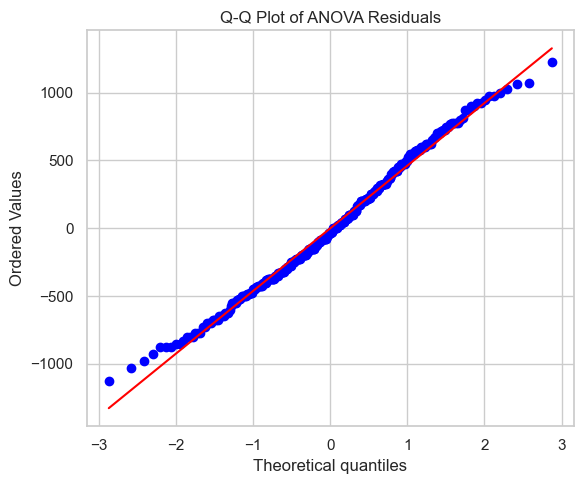

In [9]:
# Q-Q plot of pooled residuals
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(df['residuals'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot of ANOVA Residuals')
plt.tight_layout()
plt.show()

### Summary of Assumption Checks

**Normality:** Inspect the Q-Q plot and Shapiro-Wilk p-values.
- Points lying close to the diagonal line suggest the residuals are approximately normal.
- Deviations in the tails (common with the Gentoo group due to its larger overall size) indicate mild non-normality.
- ANOVA is fairly robust to moderate departures from normality, especially with balanced group sizes (n ≈ 110–150 per species here).

**What to do when assumptions are violated:**
| Violation | Recommended alternative |
|---|---|
| Unequal variances | Welch's ANOVA (`scipy` or `pingouin`) |
| Non-normal residuals | Kruskal-Wallis test (`scipy.stats.kruskal`) |
| Both | Kruskal-Wallis (non-parametric; no distributional assumption) |

---
## Task 3 — Tukey HSD Post-Hoc Comparisons

In [10]:
tukey = pairwise_tukeyhsd(endog=df['body_mass_g'], groups=df['species'], alpha=0.05)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


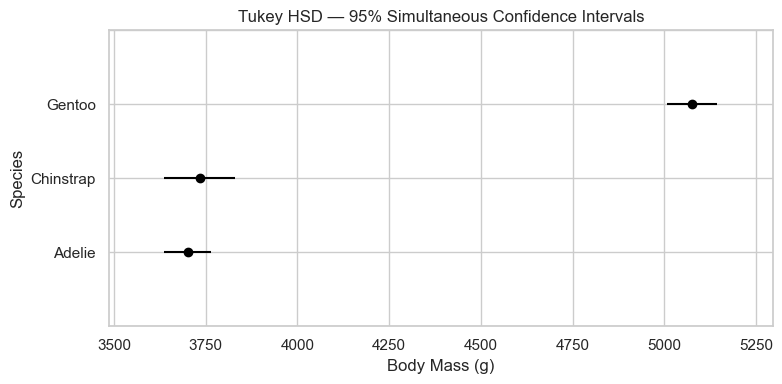

In [11]:
# Mean plot with Tukey confidence intervals
fig = tukey.plot_simultaneous(figsize=(8, 4), xlabel='Body Mass (g)', ylabel='Species')
plt.title("Tukey HSD — 95% Simultaneous Confidence Intervals")
plt.tight_layout()
plt.show()

### Interpretation

**Pairs that differ significantly (reject = True):**
- **Adelie vs Gentoo** — Gentoo penguins are substantially heavier than Adelie.
- **Chinstrap vs Gentoo** — Gentoo penguins are substantially heavier than Chinstrap.

**Pairs that do NOT differ significantly (reject = False):**
- **Adelie vs Chinstrap** — The two smaller species have similar mean body masses; the confidence interval for their difference includes zero.

**Practical size of the differences:**
The confidence intervals in the simultaneous plot are quite wide for the Gentoo comparisons, reflecting both the large absolute difference (~1 kg) and the uncertainty around it. The Adelie–Chinstrap interval straddles zero, consistent with the non-significant result. The CIs confirm that the Gentoo differences are not just statistically significant but practically meaningful.

---
## Bonus — Effect Size: Eta-Squared and Cohen's d

In [12]:
# Eta-squared (η²) = SS_between / SS_total
grand_mean = df['body_mass_g'].mean()
ss_between = sum(
    len(grp) * (grp['body_mass_g'].mean() - grand_mean) ** 2
    for _, grp in df.groupby('species')
)
ss_total = ((df['body_mass_g'] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total
print(f'η² (eta-squared) = {eta_sq:.4f}')

η² (eta-squared) = 0.6697


In [13]:
# Cohen's d for each significant pair
def cohens_d(a, b):
    pooled_sd = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2)
                        / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled_sd

pairs = [
    ('Adelie',    'Chinstrap'),
    ('Adelie',    'Gentoo'),
    ('Chinstrap', 'Gentoo'),
]
print('Cohen\'s d (absolute value):')
for g1, g2 in pairs:
    d = cohens_d(groups[g1], groups[g2])
    print(f'  {g1} vs {g2}: d = {abs(d):.3f}')

Cohen's d (absolute value):
  Adelie vs Chinstrap: d = 0.074
  Adelie vs Gentoo: d = 2.868
  Chinstrap vs Gentoo: d = 2.887


**Guidelines for Cohen's d:** small ≈ 0.2, medium ≈ 0.5, large ≥ 0.8.

Gentoo comparisons produce very large effect sizes (d > 1), confirming the practical importance of those differences. The Adelie–Chinstrap d is much smaller, consistent with the non-significant Tukey result.

---
## Bonus — η² Equals R² from Dummy-Coded Regression

In [14]:
# One-hot encode species (drop first to avoid multicollinearity)
X = pd.get_dummies(df['species'], drop_first=True).astype(float)
y = df['body_mass_g'].values

reg = LinearRegression().fit(X, y)
r2 = r2_score(y, reg.predict(X))

print(f'R² from regression : {r2:.4f}')
print(f'η²                 : {eta_sq:.4f}')
print(f'Difference         : {abs(r2 - eta_sq):.2e}  (numerical rounding only)')

R² from regression : 0.6697
η²                 : 0.6697
Difference         : 1.11e-16  (numerical rounding only)


### Why They Are Equal

Both η² and R² measure the proportion of total variance in the outcome that is explained by the grouping. In a dummy-coded OLS regression the group means are the fitted values, so SS_between = SS_regression. Dividing both by SS_total gives the same quantity. ANOVA and linear regression are algebraically the same model expressed in different notation.